# Lab 2: Predictive Analytics with Machine Learning

Student Name: Omuwa George Divine  
Student ID: 53362027


## Setup

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

## Section 1 Supervised Learning: Regression
Predicting taxi tip_amount (NYC Yellow Taxi)

### 1.1 Load and explore the taxi data

Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


Missing values per column:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


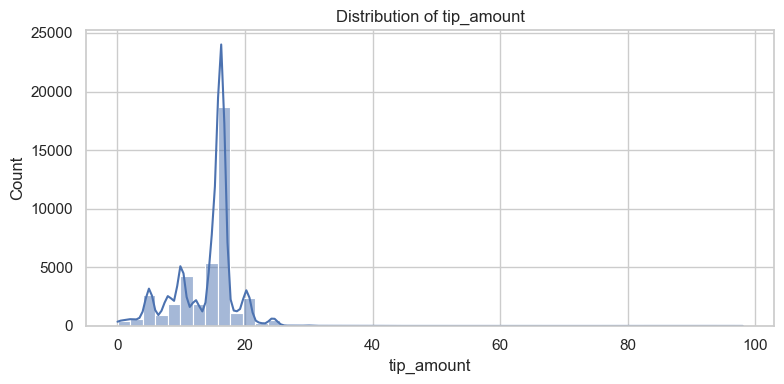

In [ ]:
taxi = pd.read_csv(TAXI_URL)

print(taxi.shape)
display(taxi.head())
taxi.info()
display(taxi.describe())
print("Missing values:")
print(taxi.isna().sum())

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(taxi["tip_amount"], bins=50, kde=True, ax=ax)
ax.set_title("Distribution of tip_amount")
ax.set_xlabel("tip_amount")
plt.tight_layout()
plt.show()

# the x value of the shape is large.

**1.1 Student Reasoning**

The dataset has 41,202 rows and 13 columns and no missing values, no negative tips, but some trips have zero or negative trip distance and should be removed before modeling. The tip amount distribution is skewed to the right so we should remove invalid distances and fare amounts


### 1.2 Preprocessing & feature engineering

In [ ]:
from sklearn.preprocessing import StandardScaler

taxi_clean = taxi.dropna().copy()

# missing/invalid rows
taxi_clean = taxi_clean[
    (taxi_clean["trip_distance"] > 0) & (taxi_clean["fare_amount"] > 0)
]
taxi_clean = taxi_clean[taxi_clean["tip_amount"] >= 0]
print(f"Cleaned rows: {len(taxi_clean)} (removed {len(taxi) - len(taxi_clean)})")

# new feature
taxi_clean["fare_per_mile"] = taxi_clean["fare_amount"] / taxi_clean["trip_distance"]
taxi_clean["total_surcharges"] = (
    taxi_clean["mta_tax"]
    + taxi_clean["tolls_amount"]
    + taxi_clean["improvement_surcharge"]
)

# categorical and numerical columns
cat_cols = ["VendorID", "RatecodeID", "store_and_fwd_flag", "payment_type"]
num_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile",
    "total_surcharges",
]

X_taxi = pd.get_dummies(
    taxi_clean[cat_cols + num_cols], columns=cat_cols, drop_first=True
)
y_taxi = taxi_clean["tip_amount"]

print("Feature matrix: ", X_taxi.shape)
display(X_taxi.head())


Rows after cleaning: 41126 (removed 76)
Feature matrix shape: (41126, 12)


,passenger_count,trip_distance,fare_amount,mta_tax,tolls_amount,improvement_surcharge,fare_per_mile,total_surcharges,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,70.0,0.5,6.94,1,3.970505,8.44,True,False,False,True
1,1,19.52,70.0,0.5,6.94,1,3.586066,8.44,True,False,False,True
2,1,17.81,70.0,0.5,6.94,1,3.930376,8.44,True,False,False,True
3,2,19.30,70.0,0.5,0.00,1,3.626943,1.50,True,False,False,True
4,1,18.75,70.0,0.5,6.94,1,3.733333,8.44,True,False,False,True


**1.2 Student Reasoning**

1. By dropping rows with negative trip distance or fare amount and keeping positive tips because negative tips are not meaningful.
2. Fare/mile and total surcharges were the new features, they relate to how much a passenger pays beyond the base fare which can change tipping.
3. The Standard Scaler scaling method was used because standardization puts them on comparable scales.


### 1.3 Train / Validation / Test split

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test_taxi, y_temp, y_test_taxi = train_test_split(
    X_taxi, y_taxi, test_size=0.2, random_state=RANDOM_STATE
)
X_train_taxi, X_val_taxi, y_train_taxi, y_val_taxi = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE
)

print(
    f"Train:{X_train_taxi.shape[0]}, Val:{X_val_taxi.shape[0]}, Test: {X_test_taxi.shape[0]}"
)

scaler_taxi = StandardScaler()
X_train_taxi_scaled = scaler_taxi.fit_transform(X_train_taxi)
X_val_taxi_scaled = scaler_taxi.transform(X_val_taxi)
X_test_taxi_scaled = scaler_taxi.transform(X_test_taxi)


Train: 24675, Val: 8225, Test: 8226


**1.3 Student Reasoning**

I used a 60 to 20 to 20 split as recommended. A seperate validation set lets us find overfitting easily. The scaler must be fit so that validation and test statistics are not leaked into preprocessing making the performancebiased.


### 1.4 Train a regressor and check for overfitting

,Model,Split,RMSE,R2
0,LinearRegression,Train,4.8047,0.0512
1,LinearRegression,Validation,5.0375,0.0485
2,LinearRegression,Test,5.0132,0.0510
3,RandomForestRegressor,Train,4.5713,0.1412
4,RandomForestRegressor,Validation,5.0726,0.0352
5,RandomForestRegressor,Test,5.0693,0.0297


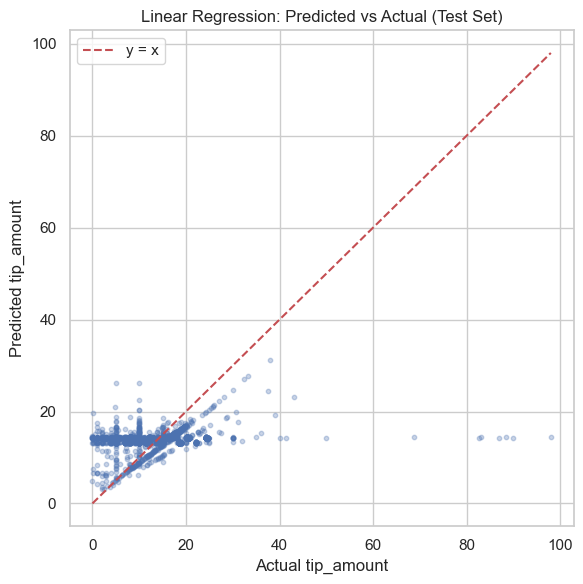

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


def regression_metrics(model, X_train, y_train, X_val, y_val, X_test, y_test, name):
    model.fit(X_train, y_train)
    rows = []
    for split, Xs, ys in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        pred = model.predict(Xs)
        rmse = mean_squared_error(ys, pred) ** 0.5
        r2 = r2_score(ys, pred)
        rows.append({"Model": name, "Split": split, "RMSE": rmse, "R2": r2})
    return pd.DataFrame(rows), model


lin_reg = LinearRegression()
lin_metrics, lin_model = regression_metrics(
    lin_reg,
    X_train_taxi_scaled,
    y_train_taxi,
    X_val_taxi_scaled,
    y_val_taxi,
    X_test_taxi_scaled,
    y_test_taxi,
    "LinearRegression",
)

rf_reg = RandomForestRegressor(
    n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf_metrics, rf_model = regression_metrics(
    rf_reg,
    X_train_taxi_scaled,
    y_train_taxi,
    X_val_taxi_scaled,
    y_val_taxi,
    X_test_taxi_scaled,
    y_test_taxi,
    "RandomForestRegressor",
)

metrics_taxi = pd.concat([lin_metrics, rf_metrics], ignore_index=True)
display(metrics_taxi.round(4))

y_pred_test = lin_model.predict(X_test_taxi_scaled)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_taxi, y_pred_test, alpha=0.3, s=10)
lims = [
    min(y_test_taxi.min(), y_pred_test.min()),
    max(y_test_taxi.max(), y_pred_test.max()),
]
ax.plot(lims, lims, "r--", label="y = x")
ax.set_xlabel("Actual tip")
ax.set_ylabel("Predicted tip")
ax.legend()
plt.tight_layout()
plt.show()


**1.4 Student Reasoning**

1. LinearRegression performed best on validation with RMSE ≈ 5.04, R² ≈ 0.048 parameters
2. TRAIN ≈ 4.80 and TEST ≈ 5.01 so it is underfitting rather than overfitting, R² ≈ 0.05 is constant.
3. To reduce overfitting you could lower the max depth


## Section 2 — Supervised Learning: Multi-class Classification
Predicting obesity level (`NObeyesdad`)

### 2.1 Load and explore the obesity data

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


Missing values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


C:\Users\uwage\AppData\Local\Temp\ipykernel_4004\2570710697.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


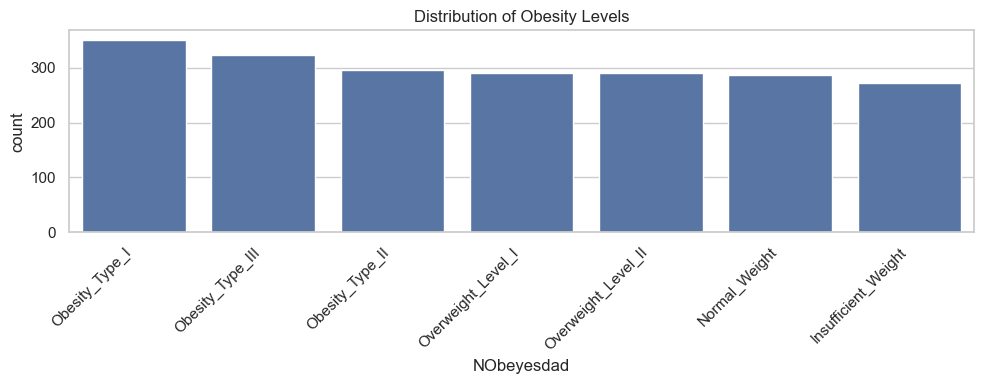

In [ ]:
obesity = pd.read_csv(OBESITY_URL)

print(obesity.shape)
display(obesity.head())
obesity.info()
display(obesity.describe(include="all"))
print("Missing values:")
print(obesity.isna().sum())

print("Class distribution:")
print(obesity["NObeyesdad"].value_counts())
fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(
    data=obesity,
    x="NObeyesdad",
    order=obesity["NObeyesdad"].value_counts().index,
    ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Class Distribution")
plt.tight_layout()
plt.show()


**2.1 Student Reasoning**
There are 2,111 rows and 17 columns. Categorical columns are Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, and MTRANS.

Numeric columns are Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE. 

The seven obesity classes are balanced. It matters for proper representation of minority classes

### 2.2 Preprocessing & feature engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder

ob = obesity.copy()

binary_map = {"yes": 1, "no": 0}
for col in ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]:
    ob[col] = ob[col].map(binary_map)

caec_map = {"Never": 0, "Rarely": 1, "Frequently": 2, "Constantly": 3}
calc_map = {"Never": 0, "Rarely": 1, "Frequently": 2, "Constantly": 3}
ob["CAEC"] = ob["CAEC"].map(caec_map)
ob["CALC"] = ob["CALC"].map(calc_map)

ob = pd.get_dummies(ob, columns=["Gender", "MTRANS"], drop_first=True)
ob["BMI"] = ob["Weight"] / (ob["Height"] ** 2)

le = LabelEncoder()
y_obesity = le.fit_transform(ob["NObeyesdad"])
class_names = le.classes_

feature_cols = [c for c in ob.columns if c != "NObeyesdad"]
X_obesity = ob[feature_cols]

print("Encoded classes:", dict(enumerate(class_names)))
print("Feature matrix shape:", X_obesity.shape)
display(X_obesity.head())


Encoded classes: {0: 'Insufficient_Weight', 1: 'Normal_Weight', 2: 'Obesity_Type_I', 3: 'Obesity_Type_II', 4: 'Obesity_Type_III', 5: 'Overweight_Level_I', 6: 'Overweight_Level_II'}
Feature matrix shape: (2111, 20)


,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,BMI
0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,False,False,False,True,False,24.386526
1,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,False,False,False,True,False,24.238227
2,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,True,False,False,True,False,23.765432
3,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,True,False,False,False,True,26.851852
4,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,True,False,False,True,False,28.342381


**1.2 Student Reasoning**
1. Binary yes and no columns were encoded as 0/1. Ordinal columns CAEC and CALC were encoded in rational order from Never to Constantly. Gender and MTRANS were one hot encoded to avoid imposing a false order.
2. I engineered BMI = Weight/Height^2. It is fair as a feature because it is gotten from readily available inputs
3. I used StandardScaler so distance and linear models are not dominated by variables with larger magnitudes.


### 2.3 Stratified Train / Validation / Test split

In [ ]:
X_temp_ob, X_test_ob, y_temp_ob, y_test_ob = train_test_split(
    X_obesity, y_obesity, test_size=0.2, random_state=RANDOM_STATE, stratify=y_obesity
)
X_train_ob, X_val_ob, y_train_ob, y_val_ob = train_test_split(
    X_temp_ob, y_temp_ob, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp_ob
)

print(
    f"Train: {X_train_ob.shape[0]}, Val: {X_val_ob.shape[0]}, Test: {X_test_ob.shape[0]}"
)

scaler_ob = StandardScaler()
X_train_ob_scaled = scaler_ob.fit_transform(X_train_ob)
X_val_ob_scaled = scaler_ob.transform(X_val_ob)
X_test_ob_scaled = scaler_ob.transform(X_test_ob)


Train: 1266, Val: 422, Test: 423


**2.3 Student Reasoning**

I used a 60 to 20 to 20 stratified split. 

Stratify=y ensures ethe proportion is the same for all 7 classes. Without stratification a random split could put few or zero examples of a class in validation/test, making accuracy unstable.


### 2.4 Train a classifier and check for overfitting

,Model,Split,Accuracy,Macro F1
0,LogisticRegression,Train,0.9242,0.9217
1,LogisticRegression,Validation,0.8791,0.8728
2,LogisticRegression,Test,0.8936,0.8895
3,RandomForestClassifier,Train,1.0000,1.0000
4,RandomForestClassifier,Validation,0.9905,0.9901
5,RandomForestClassifier,Test,0.9976,0.9975


                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       0.98      1.00      0.99        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      0.98      0.99        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1.00       423
       weighted avg       1.00      1.00      1.00       423



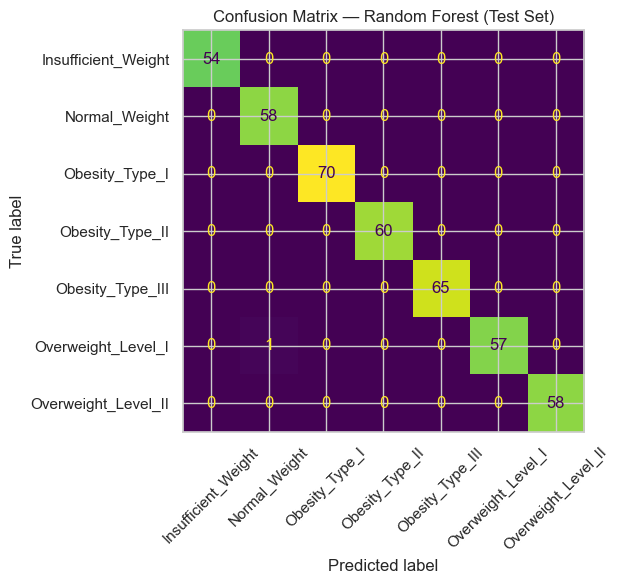

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)


def classification_metrics(model, X_train, y_train, X_val, y_val, X_test, y_test, name):
    model.fit(X_train, y_train)
    rows = []
    for split, Xs, ys in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        pred = model.predict(Xs)
        rows.append(
            {
                "Model": name,
                "Split": split,
                "Accuracy": accuracy_score(ys, pred),
                "Macro F1": f1_score(ys, pred, average="macro"),
            }
        )

    return pd.DataFrame(rows), model


log_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_metrics, log_model = classification_metrics(
    log_clf,
    X_train_ob_scaled,
    y_train_ob,
    X_val_ob_scaled,
    y_val_ob,
    X_test_ob_scaled,
    y_test_ob,
    "LogisticRegression",
)

rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf_metrics, rf_clf_model = classification_metrics(
    rf_clf,
    X_train_ob_scaled,
    y_train_ob,
    X_val_ob_scaled,
    y_val_ob,
    X_test_ob_scaled,
    y_test_ob,
    "RandomForestClassifier",
)

metrics_ob = pd.concat([log_metrics, rf_clf_metrics], ignore_index=True)
display(metrics_ob.round(4))

best_model = rf_clf_model
y_pred_test_ob = best_model.predict(X_test_ob_scaled)
print(classification_report(y_test_ob, y_pred_test_ob, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_ob,
    y_pred_test_ob,
    display_labels=class_names,
    xticks_rotation=45,
    ax=ax,
    colorbar=False,
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()


**2.4 Student Reasoning**

1. I used Random Forest as it got the most accurate validations
2. TRAIN = 1.0, TEST = ~0.988 so it is well-fitted.
3. Adjacent overweight/obesity categories are the hardest because their lifestyle and anthropometric profiles overlap.


## Section 3 Unsupervised Learning: K-Means Clustering

### 3.1 Choose k, fit K-Means, and visualise

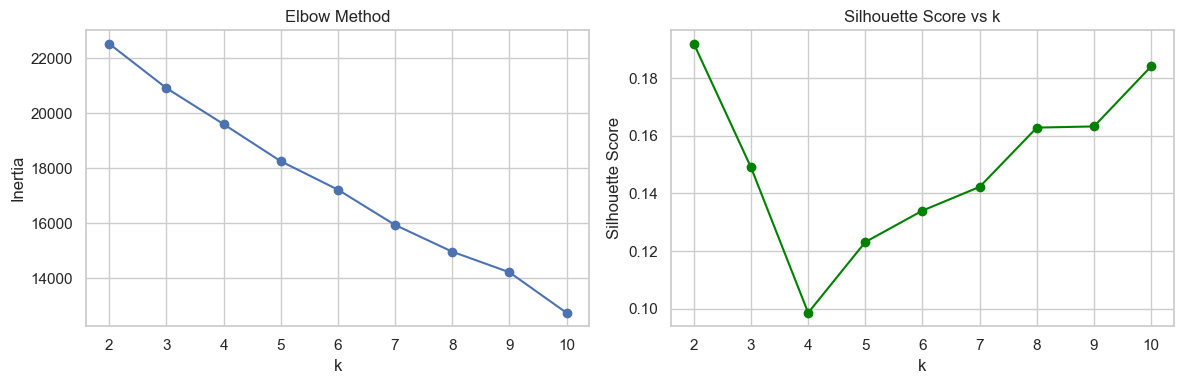

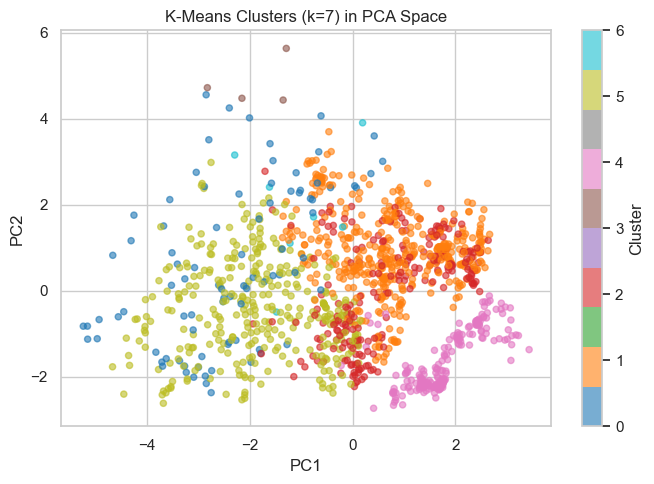

Cluster vs True Obesity Level:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,16,32,2,0,0,30,7
1,44,29,93,125,0,58,70
2,0,8,62,51,0,37,58
3,0,4,0,0,0,0,0
4,0,0,3,1,194,0,3
5,103,95,49,1,0,49,35
6,0,4,2,0,0,0,1


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_cluster = X_train_ob_scaled

ks = range(2, 10)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[1].plot(list(ks), silhouettes, marker="o", color="blue")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

chosen_k = 7
kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", alpha=0.6, s=20
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"K-Means Clusters (k={chosen_k}) in PCA Space")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

true_labels = obesity.loc[X_train_ob.index, "NObeyesdad"]
crosstab = pd.crosstab(cluster_labels, true_labels)
print("Cluster vs True Obesity Level:")
display(crosstab)


**3.1 Student Reasoning**

1. The elbow plot shows diminishing inertia reductions around 7 so k = 7 is reasonable in this case.
2. The crosstab shows some alignment, some clusters focus on specific levels like Insufficient/Normal weight, and others go to Obesity Type I.
3. In a public health setting, these clusters could be useful in identifying lifestyle profiles that are at risk for education or screening.


**Section 4 Reflection**

1. The classifier learned the exact boundary between seven labeled categories using NObeyesdad, wheareas K-Means discovered data driven groups without labels.

2. Tip evaluation with RMSE and R^2 on a continuous scale where errors are measured in dollars and low R^2 showed weak linear signal.

3. The biggest train vs test gap, train R^2 ≈0.14, test R^2≈0.03 appeared in the taxi Random Forest . The most best fix is using validation metrics to select simpler models.